<a href="https://colab.research.google.com/github/lkoc0002/MMA3001-Project-Airfoil-Noise-Prediction/blob/main/notebooks/03_Nonlinear_Regression_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Nonlinear Regression Models**

## Purpose

This notebook explores whether nonlinear regression methods can improve the prediction of airfoil sound pressure level compared with the multiple linear regression baseline.

Exploratory analysis identified substantial variation in sound pressure level across the input variables, while the baseline linear regression model achieved a test R² of approximately 0.56. This indicates that a substantial proportion of the variation in sound pressure level remains unexplained by the linear model.

Two nonlinear regression methods are investigated:
- Decision Tree Regression
- Support Vector Regression (SVR)

The models are evaluated using the same training and test data and the same performance metrics as the linear regression baseline to allow a consistent comparison.

# **Import Libraries & Load Dataset**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Define column names because the original .dat file has no header row
column_names = [
    "frequency",
    "angle_of_attack",
    "chord_length",
    "free_stream_velocity",
    "displacement_thickness",
    "sound_pressure_level"
]

# Load the experimental dataset from the project GitHub repository
data_url = "https://raw.githubusercontent.com/lkoc0002/MMA3001-Project-Airfoil-Noise-Prediction/refs/heads/main/data/airfoil_self_noise.dat"

df = pd.read_csv(
    data_url,
    sep="\t",
    names=column_names
)

df.head()

,frequency,angle_of_attack,chord_length,free_stream_velocity,displacement_thickness,sound_pressure_level
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


# **Developing Model**

In [3]:
# Separate the five input variables from the prediction target
X = df[
    [
        "frequency",
        "angle_of_attack",
        "chord_length",
        "free_stream_velocity",
        "displacement_thickness"
    ]
]

y = df["sound_pressure_level"]

# Split the training and testing data
# Use the same 80/20 split and random state as the baseline model
# so all regression methods are evaluated on the same observations
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 1202
Testing observations: 301


## Decision Tree Regression

Decision tree regression predicts an output by recursively dividing the input space into regions based on the input variables. Unlike linear regression, a decision tree does not assume that the relationship between the inputs and sound pressure level is linear.

This makes it suitable for investigating whether nonlinear relationships and interactions between the airfoil operating parameters can improve prediction.

An initial decision tree model is developed before optimisation. Model
complexity and overfitting will be investigated separately during the
optimisation stage of the project.

In [4]:
# Develop an initial decision tree without restricting tree depth
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

# Generate predictions for training and test observations
tree_train_pred = decision_tree.predict(X_train)
tree_test_pred = decision_tree.predict(X_test)

In [5]:
# Calculate training and test performance using the same metrics as the baseline
tree_train_mae = mean_absolute_error(y_train, tree_train_pred)
tree_train_rmse = np.sqrt(mean_squared_error(y_train, tree_train_pred))
tree_train_r2 = r2_score(y_train, tree_train_pred)

tree_test_mae = mean_absolute_error(y_test, tree_test_pred)
tree_test_rmse = np.sqrt(mean_squared_error(y_test, tree_test_pred))
tree_test_r2 = r2_score(y_test, tree_test_pred)

tree_results = pd.DataFrame({
    "Metric": ["MAE (dB)", "RMSE (dB)", "R²"],
    "Training": [
        tree_train_mae,
        tree_train_rmse,
        tree_train_r2
    ],
    "Testing": [
        tree_test_mae,
        tree_test_rmse,
        tree_test_r2
    ]
})

tree_results

,Metric,Training,Testing
0,MAE (dB),0.0,1.734007
1,RMSE (dB),0.0,2.424082
2,R²,1.0,0.882708


# **Measured vs Predicted: Decision Tree Regression**

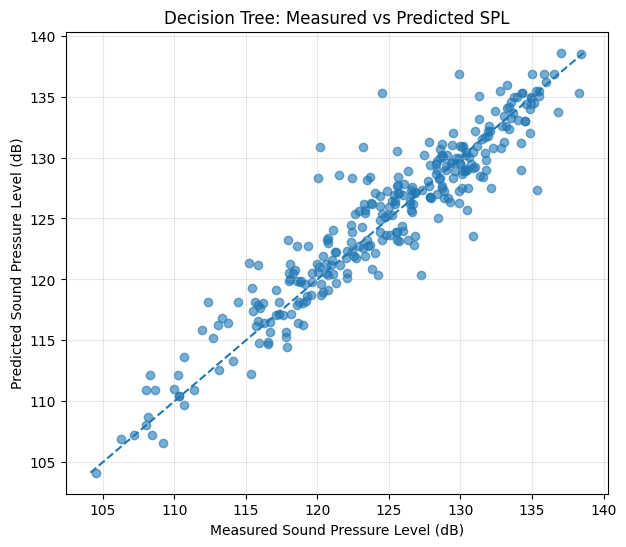

In [6]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    tree_test_pred,
    alpha=0.6
)

minimum = min(y_test.min(), tree_test_pred.min())
maximum = max(y_test.max(), tree_test_pred.max())

# Perfect prediction reference line
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Measured Sound Pressure Level (dB)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title("Decision Tree: Measured vs Predicted SPL")
plt.grid(alpha=0.3)

plt.show()

### Decision Tree Performance Results

The initial Decision Tree Regression model achieved a test MAE of approximately 1.73 dB, a test RMSE of 2.42 dB and a test R² of approximately 0.88.

The model achieved zero error and an R² of 1.00 on the training data, indicating that the unrestricted decision tree fitted the training observations exactly. Although test performance remained strong, the large difference between perfect
training performance and lower test performance indicates that the model may be overfitting the training data.

Compared with the linear regression baseline, the decision tree produced
substantially lower test prediction errors and explained a greater proportion of the variation in sound pressure level. This provides further evidence that nonlinear relationships and interactions between the input variables are important for predicting airfoil noise.

The measured-versus-predicted plot shows that most predictions lie relatively close to the perfect-prediction reference line, although several larger prediction errors remain. The potential overfitting of the unrestricted tree
will therefore be investigated by controlling model complexity during the optimisation stage.

## Support Vector Regression

Support Vector Regression (SVR) provides an alternative nonlinear modelling approach. Using a nonlinear kernel allows SVR to represent relationships between the input variables and sound pressure level without assuming a linear
relationship.

Unlike decision trees, SVR is sensitive to the numerical scale of the input variables. The airfoil dataset contains variables with substantially different scales, such as frequency measured in thousands of hertz and displacement thickness measured in fractions of a metre. The input variables are therefore standardised before training the SVR model.

In [11]:
# Fit the scaler using training data only to avoid information leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the withheld test data
X_test_scaled = scaler.transform(X_test)

# Do not transform X before splitting because then information from the test set would cause leakage and bias the target.

In [12]:
# Training the SVR model
# Develop an initial nonlinear SVR model using the radial basis function kernel
svr_model = SVR(
    kernel="rbf"
)

svr_model.fit(X_train_scaled, y_train)

# Generate predictions for training and test observations
svr_train_pred = svr_model.predict(X_train_scaled)
svr_test_pred = svr_model.predict(X_test_scaled)

In [13]:
# Evaluating model:
# Calculate training and test performance using the same evaluation metrics
svr_train_mae = mean_absolute_error(y_train, svr_train_pred)
svr_train_rmse = np.sqrt(mean_squared_error(y_train, svr_train_pred))
svr_train_r2 = r2_score(y_train, svr_train_pred)

svr_test_mae = mean_absolute_error(y_test, svr_test_pred)
svr_test_rmse = np.sqrt(mean_squared_error(y_test, svr_test_pred))
svr_test_r2 = r2_score(y_test, svr_test_pred)

svr_results = pd.DataFrame({
    "Metric": ["MAE (dB)", "RMSE (dB)", "R²"],
    "Training": [
        svr_train_mae,
        svr_train_rmse,
        svr_train_r2
    ],
    "Testing": [
        svr_test_mae,
        svr_test_rmse,
        svr_test_r2
    ]
})

svr_results

,Metric,Training,Testing
0,MAE (dB),2.711895,2.831572
1,RMSE (dB),3.714375,3.721318
2,R²,0.705928,0.723581


# **Measured vs Predicted: SVR model**

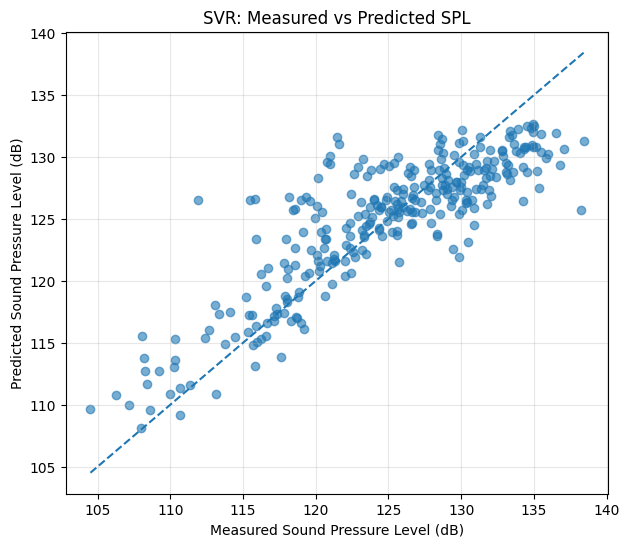

In [10]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    svr_test_pred,
    alpha=0.6
)

minimum = min(y_test.min(), svr_test_pred.min())
maximum = max(y_test.max(), svr_test_pred.max())

# Perfect prediction reference line
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Measured Sound Pressure Level (dB)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title("SVR: Measured vs Predicted SPL")
plt.grid(alpha=0.3)

plt.show()

### SVR Performance Results

The initial Support Vector Regression model achieved a test MAE of approximately 2.83 dB, a test RMSE of 3.72 dB and a test R² of approximately 0.72.

Training and testing performance were very similar, with training and test RMSE values of approximately 3.71 dB and 3.72 dB respectively. This indicates that there is no obvious large generalisation gap between the training and test data.

Compared with the linear regression baseline, the initial SVR model produced lower prediction errors and explained a greater proportion of the variation in sound pressure level. This provides evidence that modelling nonlinear relationships between the input variables improves predictive performance.

The measured vs predicted plot shows that many predictions follow the
perfect prediction reference line reasonably closely, although prediction errors remain. Some deviation is particularly visible at higher measured sound pressure levels, which will be investigated further during model comparison
and optimisation.

## Findings

Both nonlinear regression models improved prediction performance compared with the multiple linear regression baseline.

The initial Support Vector Regression model achieved a test MAE of approximately 2.83 dB, RMSE of 3.72 dB and R² of 0.72. Its training and testing performance were very similar, indicating good generalisation without a big large train test performance gap.

The unrestricted Decision Tree Regression model achieved the strongest test performance, with a test MAE of approximately 1.73 dB, RMSE of 2.42 dB and R² of 0.88. However, it achieved zero training error and an R² of 1.00 on the
training data. This perfect training fit, combined with lower performance on unseen test data, indicates potential overfitting and suggests that the tree is more complex than necessary.

Compared with the linear regression baseline, which achieved a test RMSE of approximately 4.70 dB and R² of 0.56, the results provide evidence that
nonlinear modelling better represents the relationships between the airfoil
input variables and sound pressure level.

The results do not yet establish which model provides the best overall approach. The next stage will investigate model complexity and parameter selection,
specifically whether controlling the complexity in the decision tree model can retain strong predictive performance while reducing overfitting, and whether optimisation can further improve SVR performance. The optimised models will then be compared using consistent validation criteria.